# A2 - A3

In [2]:
import pandas as pd

df = pd.read_excel(r"C:\Users\ivysa\OneDrive\Desktop\College Projects\ML\Lab Session Data.xlsx", sheet_name="marketing_campaign")

# nominal
def OneHotEncoding(df, column):
    uniqueCols = df[column].unique()
    for col in uniqueCols:
        s = df[column] == col                #boolean outcome
        df[col] = s.astype(int)              # converting to Os and 1s i.e encoding and creates and stores in new columns
    return df[uniqueCols]

#ordinal
def LabelEncoding(df, column):
    myDict = {}
    ucols = df[column].unique()
    for i in range(len(ucols)):
        myDict[ucols[i]] = i
    return df[column].map(myDict)            # appends values for all rows (keys) from the dictionary to empty list by looping

res = OneHotEncoding(df, "Marital_Status")
print("One Hot Encoding")
print(res)

print("\nLabel Encoding")
print(LabelEncoding(df, "Education"))

One Hot Encoding
      Single  Together  Married  Divorced  Widow  Alone  Absurd  YOLO
0          1         0        0         0      0      0       0     0
1          1         0        0         0      0      0       0     0
2          0         1        0         0      0      0       0     0
3          0         1        0         0      0      0       0     0
4          0         0        1         0      0      0       0     0
...      ...       ...      ...       ...    ...    ...     ...   ...
2235       0         0        1         0      0      0       0     0
2236       0         1        0         0      0      0       0     0
2237       0         0        0         1      0      0       0     0
2238       0         1        0         0      0      0       0     0
2239       0         0        1         0      0      0       0     0

[2240 rows x 8 columns]

Label Encoding
0       0
1       0
2       0
3       0
4       1
       ..
2235    0
2236    1
2237    0
2238    2
22

# A4

In [24]:
def MinkowskiDist(p, X, Y):
    sum = 0
    for i in range(len(X)):
        sum += abs(X[i] - Y[i])**p
    return (sum)**(1/p)

X = [2,-1,3]
Y = [1,4,-2]
# n = int(input("Enter dimension:"))
# for _ in range(n):
#     print("Enter for X")
#     X.append(int(input()))
# for _ in range(n):
#     print("Enter for Y")
#     Y.append(int(input()))
print("Manhattan distance")
print(MinkowskiDist(1, X, Y))
print("Euclidean distance")
print(MinkowskiDist(2, X, Y))

Manhattan distance
11.0
Euclidean distance
7.14142842854285


# A5

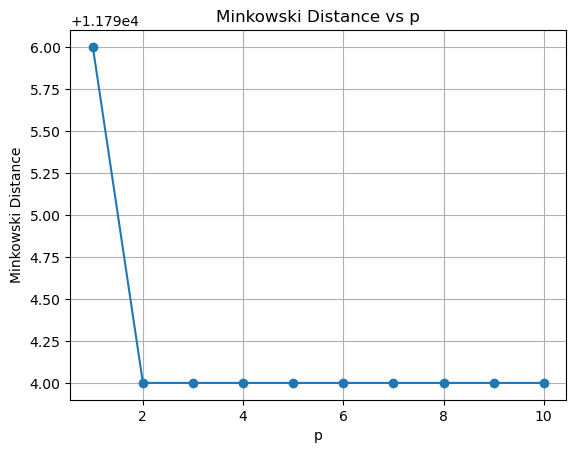

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

def MinkowskiDist(p, X, Y):
    sum = 0
    for i in range(len(X)):
        sum += abs(X[i] - Y[i])**p
    return (sum)**(1/p)

df = pd.read_excel(r"C:\Users\ivysa\OneDrive\Desktop\College Projects\ML\Lab Session Data.xlsx", sheet_name="marketing_campaign")
f = df.loc[[0,1]]
X = df.loc[0, ["Income", "Kidhome", "Teenhome"]]
Y = df.loc[1, ["Income", "Kidhome", "Teenhome"]]
distances = []
for i in range(1, 11):
    d = MinkowskiDist(i, X, Y)
    distances.append(d)

plt.plot(range(1, 11), distances, marker='o')
plt.xlabel("p")
plt.ylabel("Minkowski Distance")
plt.title("Minkowski Distance vs p")
plt.grid(True)
plt.savefig("minkowski_dist.png")
plt.show()

# A6

In [4]:
import pandas as pd
from scipy.spatial.distance import minkowski

def MinkowskiDist(X, Y, p):
    if len(X) != len(Y):
        raise ValueError("Both feature vectors must have the same dimensions.")

    distance = 0

    for i in range(len(X)):
        distance += abs(X[i] - Y[i]) ** p

    distance = distance ** (1 / p)

    if p == 1:
        print("It is Manhattan Distance.")
    elif p == 2:
        print("It is Euclidean Distance.")
    return distance

df = pd.read_excel(r"C:\Users\ivysa\OneDrive\Desktop\College Projects\ML\Lab Session Data.xlsx", sheet_name="marketing_campaign"
)

numeric_df = df.select_dtypes(include="number")

X = numeric_df.iloc[0].values
Y = numeric_df.iloc[1].values

p = 3

my_distance = MinkowskiDist(X, Y, p)
scipy_distance = minkowski(X, Y, p)

print("Distance using user-defined function :", my_distance)
print("Distance using scipy function        :", scipy_distance)

Distance using user-defined function : 11884.37455405266
Distance using scipy function        : 11884.37455405266


# A7

In [7]:
def DotProduct(A, B):
    if len(A) != len(B):
        raise ValueError("Vectors must have the same number of dimensions.")
    dot = 0
    for i in range(len(A)):
        dot += A[i] * B[i]
    return dot

def EuclideanNorm(A):
    sum = 0
    for i in range(len(A)):
        sum += A[i] ** 2
    return sum ** 0.5

A = [2, 4, 6, 8]
B = [1, 3, 5, 7]

dot_product = DotProduct(A, B)

length_A = EuclideanNorm(A)
length_B = EuclideanNorm(B)

print("Vector A:", A)
print("Vector B:", B)

print("\nDot Product of A and B:", dot_product)
print("Length of A:", length_A)
print("Length of B:", length_B)

print("\nDot Product of A and B using NumPy:", np.dot(A, B))
print("Length of A:", np.linalg.norm(A))
print("Length of B:", np.linalg.norm(B))

Vector A: [2, 4, 6, 8]
Vector B: [1, 3, 5, 7]

Dot Product of A and B: 100
Length of A: 10.954451150103322
Length of B: 9.16515138991168

Dot Product of A and B using NumPy: 100
Length of A: 10.954451150103322
Length of B: 9.16515138991168


# A8

In [5]:
import pandas as pd

def Mean(data):
    total = 0
    for value in data:
        total += value
    return total / len(data)

def Variance(data):
    mean = Mean(data)
    variance = 0
    for value in data:
        variance += (value - mean) ** 2

    return variance / len(data)      # Population Variance


def StandardDeviation(data):
    variance = Variance(data)
    return variance ** 0.5

def FeatureStatistics(df):
    statistics = pd.DataFrame(
        columns=["Feature", "Mean", "Variance", "Standard Deviation"]
    )

    for column in df.columns:
        statistics.loc[len(statistics)] = [
            column,
            Mean(df[column]),
            Variance(df[column]),
            StandardDeviation(df[column])
        ]

    return statistics

df = pd.read_excel(r"C:\Users\ivysa\OneDrive\Desktop\College Projects\ML\Lab Session Data.xlsx", sheet_name="marketing_campaign"
)

numeric_df = df.select_dtypes(include="number")
result = FeatureStatistics(numeric_df)
print(result)

                Feature         Mean      Variance  Standard Deviation
0                    ID  5592.159821  1.053611e+07         3245.937415
1            Year_Birth  1968.805804  1.435538e+02           11.981394
2                Income          NaN           NaN                 NaN
3               Kidhome     0.444196  2.897431e-01            0.538278
4              Teenhome     0.506250  2.963895e-01            0.544417
5               Recency    49.109375  8.384492e+02           28.955987
6              MntWines   303.935714  1.132472e+05          336.522251
7             MntFruits    26.302232  1.581220e+03           39.764555
8       MntMeatProducts   166.950000  5.092469e+04          225.664984
9       MntFishProducts    37.525446  2.982993e+03           54.616784
10     MntSweetProducts    27.062946  1.703319e+03           41.271283
11         MntGoldProds    44.021875  2.720227e+03           52.155793
12    NumDealsPurchases     2.325000  3.731875e+00            1.931806
13    

# A9

In [6]:
import pandas as pd
import numpy as np

def Mean(data):
    total = 0
    for value in data:
        total += value
    return total / len(data)


def Variance(data):
    mean = Mean(data)
    variance = 0
    for value in data:
        variance += (value - mean) ** 2
    return variance / len(data)

def StandardDeviation(data):
    return Variance(data) ** 0.5


def ManualStatistics(df):
    means = []
    stds = []

    for column in df.columns:
        means.append(Mean(df[column]))
        stds.append(StandardDeviation(df[column]))

    return means, stds


df = pd.read_excel(r"C:\Users\ivysa\OneDrive\Desktop\College Projects\ML\Lab Session Data.xlsx", sheet_name="marketing_campaign")

numeric_df = df.select_dtypes(include="number")

manual_mean, manual_std = ManualStatistics(numeric_df)

numpy_mean = np.mean(numeric_df, axis=0)
numpy_std = np.std(numeric_df, axis=0)

comparison = pd.DataFrame({
    "Manual Mean": manual_mean,
    "NumPy Mean": numpy_mean,
    "Manual Std Dev": manual_std,
    "NumPy Std Dev": numpy_std
})

print(comparison)

                     Manual Mean    NumPy Mean  Manual Std Dev  NumPy Std Dev
ID                   5592.159821   5592.159821     3245.937415    3245.937415
Year_Birth           1968.805804   1968.805804       11.981394      11.981394
Income                       NaN  52247.251354             NaN   25167.396174
Kidhome                 0.444196      0.444196        0.538278       0.538278
Teenhome                0.506250      0.506250        0.544417       0.544417
Recency                49.109375     49.109375       28.955987      28.955987
MntWines              303.935714    303.935714      336.522251     336.522251
MntFruits              26.302232     26.302232       39.764555      39.764555
MntMeatProducts       166.950000    166.950000      225.664984     225.664984
MntFishProducts        37.525446     37.525446       54.616784      54.616784
MntSweetProducts       27.062946     27.062946       41.271283      41.271283
MntGoldProds           44.021875     44.021875       52.155793  

# A10

Feature: MFCC_1_mean
Mean: -212.22940371474763
Variance: 5916.229404725934

Histogram Frequencies:
[  21  124  191   96  197  598 1041  595  130   21]

Bucket Edges:
[-474.13186646 -429.58771191 -385.04355736 -340.49940281 -295.95524826
 -251.41109371 -206.86693916 -162.32278461 -117.77863007  -73.23447552
  -28.69032097]


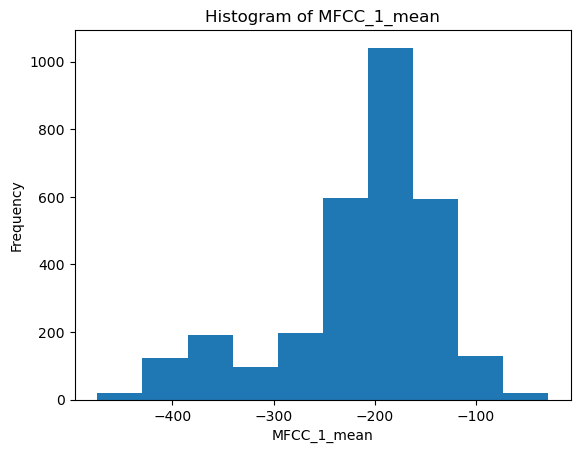

In [2]:
import os
import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt

def extract_mfcc_features(file_path):
    signal, sample_rate = librosa.load(file_path, sr=None)
    mfcc = librosa.feature.mfcc(
        y=signal,
        sr=sample_rate,
        n_mfcc=13
    )
    mfcc_mean = np.mean(mfcc, axis=1)
    mfcc_std = np.std(mfcc, axis=1)
    features = np.concatenate([mfcc_mean, mfcc_std])

    return features

train_path = r"D:\ASV_2017\baseline_CM\baseline_CM\ASVspoof2017_V2_train"

data = []
for filename in os.listdir(train_path):
    if filename.lower().endswith(".wav"):
        file_path = os.path.join(train_path, filename)
        features = extract_mfcc_features(file_path)
        data.append([filename] + features.tolist())

feature_names = []

for i in range(1, 14):
    feature_names.append(f"MFCC_{i}_mean")

for i in range(1, 14):
    feature_names.append(f"MFCC_{i}_std")

columns = ["filename"] + feature_names

df = pd.DataFrame(data, columns=columns)

feature = df["MFCC_1_mean"].to_numpy()

mean = np.mean(feature)
variance = np.var(feature)

print("Feature: MFCC_1_mean")
print("Mean:", mean)
print("Variance:", variance)

frequency, bin_edges = np.histogram(feature, bins=10)

print("\nHistogram Frequencies:")
print(frequency)
print("\nBucket Edges:")
print(bin_edges)
plt.hist(feature, bins=10)
plt.xlabel("MFCC_1_mean")
plt.ylabel("Frequency")
plt.title("Histogram of MFCC_1_mean")
plt.savefig("mfcc_hist.png")
plt.show()

# A11

In [6]:
import numpy as np
import pandas as pd

df = pd.read_excel(
    r"C:\Users\ivysa\OneDrive\Desktop\College Projects\ML\Lab Session Data.xlsx",
    sheet_name="marketing_campaign"
)

data = df[["Income", "Kidhome", "Teenhome"]].copy()

data["Income"] = data["Income"].fillna(data["Income"].median())

for col in data.columns:
    minimum = data[col].min()
    maximum = data[col].max()

    data[col] = (
        data[col] - minimum
    ) / (maximum - minimum)

X = data.values

def Mean(data):
    total = 0
    for value in data:
        total += value
    return total / len(data)


def MinkowskiDist(X, Y, p):
    if len(X) != len(Y):
        raise ValueError("Both feature vectors must have the same dimensions.")
    distance = 0
    for i in range(len(X)):
        distance += abs(X[i] - Y[i]) ** p
    return distance ** (1 / p)

K = 3

centroids = X[:K].copy()

for iteration in range(100):

    clusters = []

    for point in X:
        distances = []
        for centroid in centroids:
            distance = MinkowskiDist(point, centroid, 2)
            distances.append(distance)
        cluster = np.argmin(distances)
        clusters.append(cluster)
    clusters = np.array(clusters)

    new_centroids = []

    for k in range(K):
        cluster_points = X[clusters == k]
        if len(cluster_points) > 0:
            new_centroid = Mean(cluster_points)
        else:
            new_centroid = centroids[k]
        new_centroids.append(new_centroid)
    new_centroids = np.array(new_centroids)
    if np.array_equal(centroids, new_centroids):
        print("Converged after", iteration + 1, "iterations")
        break
    centroids = new_centroids
    
print("\nFinal Centroids:")
print(centroids)
print("\nCluster Assignment:")
print(clusters)

Converged after 4 iterations

Final Centroids:
[[0.0842585  0.01624815 0.53840473]
 [0.05603161 0.52594595 0.21891892]
 [0.09604429 0.         0.        ]]

Cluster Assignment:
[2 1 2 ... 2 0 1]
